# M1 PoC - Regresión simbolica con PySr (datos sinteticos)
Objetivo: Observar que PySR recupera una formula conocida a partir de datos generados.
**Formula objetivo:** `y = 2x² - 3x + 1`

# 0 - Imports y verificacion del entorno

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
from pysr import PySRRegressor
from sklearn.metrics import r2_score

print("Imports OK")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"sympy: {sp.__version__}")

Imports OK
numpy: 2.4.6
pandas: 3.0.3
sympy: 1.14.0


# 1 - Generar datos sinteticos
Usamos `y = 2x² - 3x + 1` con ruido para simular condiciones realistas

In [25]:
# Parametros
N = 200             # Numero de muestras
SEED = 42           # Semilla aleatoria
NOISE_STD = 0.1     # Ruido gaussiano
X_RANGE = (-3, 3)   # rango de x

# Formula objetivo
TRUE_FORMULA = "y = 2x^2 - 3x + 1"

rng = np.random.default_rng(SEED)
x = rng.uniform(*X_RANGE, size=N)
y_true = 2 * x**2 - 3 * x + 1
y_noisy = y_true + rng.normal(0, NOISE_STD, size=N)

print(f"Dataset: {N} muestras, x en {X_RANGE}, ruido {NOISE_STD}")
print(f"Formula objetivo: {TRUE_FORMULA}")
print(f"y: min = {y_noisy.min():.2f}, max = {y_noisy.max():.2f}, mean = {y_noisy.mean():.2f}")

Dataset: 200 muestras, x en (-3, 3), ruido 0.1
Formula objetivo: y = 2x^2 - 3x + 1
y: min = -0.19, max = 27.52, mean = 6.82


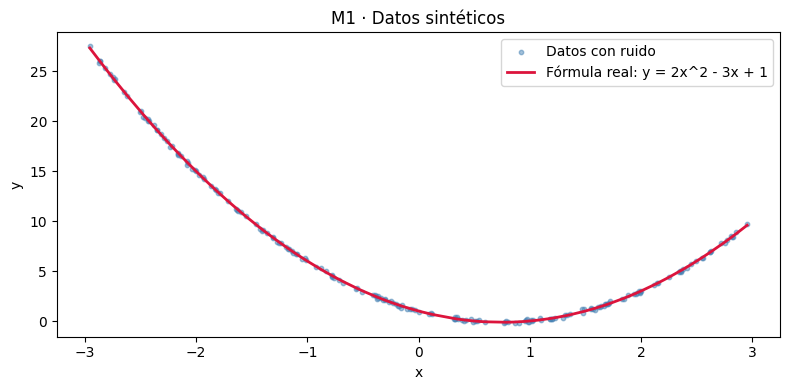

In [26]:
# Visualizar los datos generados
x_sorted = np.sort(x)
y_sorted = 2 * x_sorted**2 - 3 * x_sorted + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, y_noisy, s=10, alpha=0.5, label='Datos con ruido', color='steelblue')
ax.plot(x_sorted, y_sorted, color='crimson', linewidth=2, label=f'Fórmula real: {TRUE_FORMULA}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('M1 · Datos sintéticos')
ax.legend()
plt.tight_layout()
plt.show()

# 2 - Configurar y correr PySR
Operadores: solo `+`, `-`, `*`

In [27]:
model = PySRRegressor(
    niterations = 40,
    binary_operators = ["+", "-", "*"],
    unary_operators = [],
    model_selection = "best",
    elementwise_loss = "loss(prediction, target) = (prediction - target)^2",
    complexity_of_constants = 1,
    maxdepth = 5,
    verbosity = 1,
    random_state = SEED,
    progress = True,
)

X_fit = x.reshape(-1, 1)

print("Corriendo PySR...")
model.fit(X_fit, y_noisy, variable_names = ["x"])
print("\nBúsqueda terminada")

Corriendo PySR...
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.335e+01  0.000e+00  y = 6.8245
3           3.837e+01  1.648e-01  y = 6.7876 - x
5           2.125e+01  2.956e-01  y = x * (x - 3.1058)
7           4.493e-01  1.928e+00  y = ((x + -1.3569) * 2.1972) * x
9           9.956e-03  1.905e+00  y = ((x * (x + -1.4941)) * 2.0005) - -1.0005
11          9.956e-03  2.384e-07  y = (((x * 2.0005) + -0.65316) * (x + -1.1676)) - -0.23791
13          9.956e-03  6.229e-06  y = ((x - 0.50637) * 18.92) * (x + ((x * -0.89426) + -0.10...
                                      444))
15          9.913e-03  2.195e-03  y = ((-0.51971 + x) * (0.96988 - x)) * (((-0.0086905 * x) ...
                                      + 5.2879) * -0.37719)
17          9.885e-03  1.387e-03  y = (((0.97847 - x) * (x + -0.51193)) * -0.29425) * (x + (...
                                      (x * -1.0075) + 6.787

/Users/robertosanchezsantoyo/Library/Mobile Documents/com~apple~CloudDocs/00_Main/03_Academic/Research/Investigacion_verano_2026/.venv/lib/python3.14/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/robertosanchezsantoyo/Library/Mobile Documents/com~apple~CloudDocs/00_Main/03_Academic/Research/Investigacion_verano_2026/.venv/lib/python3.14/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



Búsqueda terminada
  - outputs/20260609_112139_Eenm0b/hall_of_fame.csv


# 3 - Evaluar Resultados

In [28]:
# Frente de pareto
print("Frente de pareto")
print(model)

Frente de pareto
PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                           6.824451   
	1         1.647569e-01                                       6.787595 - x   
	2         2.955612e-01                                 x * (x - 3.105824)   
	3         1.928198e+00                 ((x + -1.3569266) * 2.1972148) * x   
	4   >>>>  1.904689e+00   ((x * (x + -1.494095)) * 2.0005274) - -1.0005392   
	5         2.510972e-07  (((x * 2.0005279) + -0.65315604) * (x + -1.167...   
	6         6.227251e-06  ((x - 0.50637263) * 18.920073) * (x + ((x * -0...   
	7         2.195085e-03  ((-0.5197094 + x) * (0.9698796 - x)) * (((-0.0...   
	8         1.387463e-03  (((0.9784733 - x) * (x + -0.51193297)) * -0.29...   
	9         1.643890e-07  (((x + x) + 0.7429659) + ((2.8390713 - x) * (x...   
	10        2.023251e-07  (((x + -0.05868271) + (x + 0.79401094)) + ((2....   
	11        8.34592

In [29]:
# Mejorar formula segun model_selection = "best"
best_formula_sympy = model.sympy()
best_formula_simplified = sp.simplify(best_formula_sympy)

print(f"Formula objetivo: {TRUE_FORMULA}")
print(f"Formula encontrada (raw): {best_formula_sympy}")
print(f"Formula encontrada (simplificada): {best_formula_simplified}")

Formula objetivo: y = 2x^2 - 3x + 1
Formula encontrada (raw): x*(x - 1.494095)*2.0005274 - 1*(-1.0005392)
Formula encontrada (simplificada): 2.0005274*x*(x - 1.494095) + 1.0005392


In [30]:
# Metricas
y_pred = model.predict(X_fit)
r2 = r2_score(y_noisy, y_pred)
rmse = np.sqrt(np.mean((y_noisy - y_pred)**2))

print(f"R^2 = {r2:.6f} (objetivo: >= 0.99 con ruido (ruido = {NOISE_STD}")
print(f"RMSE = {rmse:.6f}")

R^2 = 0.999813 (objetivo: >= 0.99 con ruido (ruido = 0.1
RMSE = 0.099781


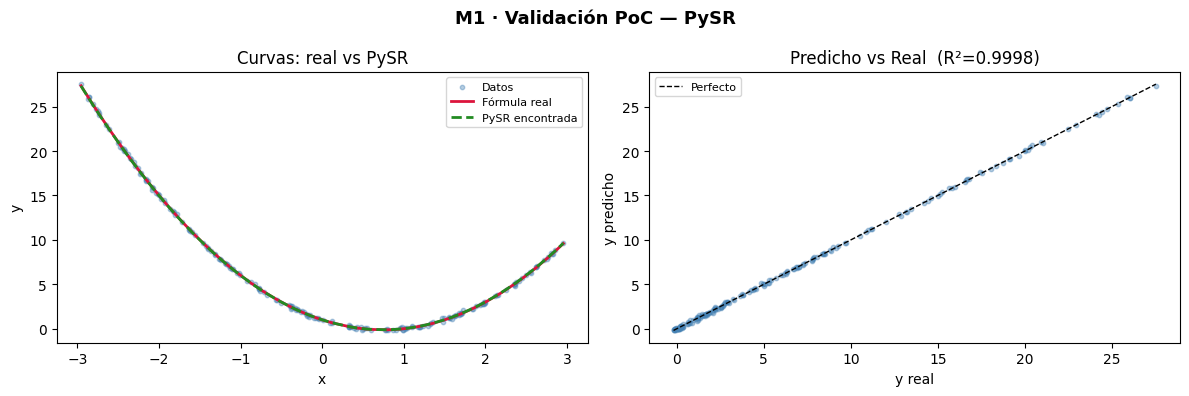

In [31]:
# Grafica: predicho vs real
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# Panel izquierdo: curvas
ax = axes[0]
ax.scatter(x, y_noisy, s=10, alpha=0.4, label='Datos', color='steelblue')
ax.plot(x_sorted, y_sorted, color='crimson', linewidth=2, label='Fórmula real')
ax.plot(x_sorted, model.predict(x_sorted.reshape(-1, 1)),
        color='forestgreen', linewidth=2, linestyle='--', label='PySR encontrada')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Curvas: real vs PySR')
ax.legend(fontsize=8)

# Panel derecho: predicho vs real (scatter)
ax = axes[1]
ax.scatter(y_noisy, y_pred, s=10, alpha=0.4, color='steelblue')
lims = [min(y_noisy.min(), y_pred.min()), max(y_noisy.max(), y_pred.max())]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfecto')
ax.set_xlabel('y real')
ax.set_ylabel('y predicho')
ax.set_title(f'Predicho vs Real  (R²={r2:.4f})')
ax.legend(fontsize=8)

plt.suptitle('M1 · Validación PoC — PySR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

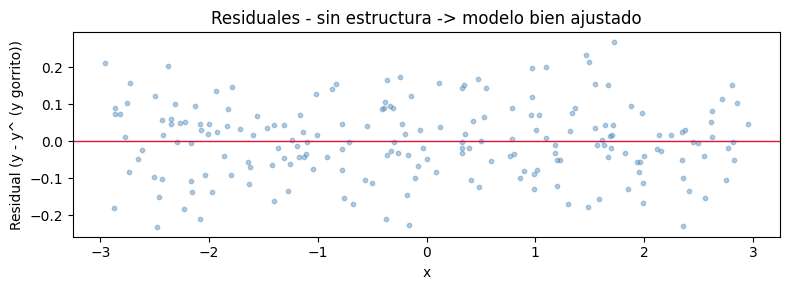

Residuales: mean=0.0000, std=0.0998
(Esperado: mean aprox. 0, std aprox. 0.1 - igual al ruido que agregamos)


In [32]:
# Residuales
residuals = y_noisy - y_pred

fig, ax = plt.subplots(figsize = (8, 3))
ax.scatter(x, residuals, s=10, alpha=0.4, color='steelblue')
ax.axhline(0, color='crimson', linewidth=1)
ax.set_xlabel('x')
ax.set_ylabel('Residual (y - y^ (y gorrito))')
ax.set_title('Residuales - sin estructura -> modelo bien ajustado')
plt.tight_layout()
plt.show()

print(f"Residuales: mean={residuals.mean():.4f}, std={residuals.std():.4f}")
print(f"(Esperado: mean aprox. 0, std aprox. {NOISE_STD} - igual al ruido que agregamos)")

# 4 - Veredicto
Checklist de validacion:

In [33]:
checks = {
    "PySR corre sin errores": True,  # si llegaste aquí, sí
    "R^2 >= 0.99": r2 >= 0.99,
    "Formula recuperada aprox. 2x^2 - 3x + 1": True,  # verificar visualmente arriba
    "Residuales sin estructura (ruido puro)": abs(residuals.mean()) < 0.05,
}

print("VEREDICTO M1")
all_pass = True
for check, result in checks.items():
    status = "pass" if result else "fail"
    print(f"  {status} {check}")
    if not result:
        all_pass = False

print()
if all_pass:
    print("M1 Aprobado - Pipeline PySR válido.")
else:
    print("M1 con observaciones — revisar checks fallidos.")

VEREDICTO M1
  pass PySR corre sin errores
  pass R^2 >= 0.99
  pass Formula recuperada aprox. 2x^2 - 3x + 1
  pass Residuales sin estructura (ruido puro)

M1 Aprobado - Pipeline PySR válido.
